# Duchenne Muscular Dystrophy: CRISPR-Corrected Isogenic Transcriptomics

## 02 — Functional Enrichment Analysis (GSEA)

Using the per-day differential expression results from `01_data_exploration.ipynb`, this notebook tests for enrichment of the 50 MSigDB Hallmark gene sets at each of the 5 differentiation time points, using `gseapy`, to see whether pathway-level effects (myogenesis, inflammation) reported in the original study are reproduced, and how they evolve across differentiation.


In [1]:
import pandas as pd
from pathlib import Path

processed_dir = Path("../data/processed")

metadata = pd.read_csv(processed_dir / "sample_metadata.csv", index_col=0)

days = [-1, 0, 2, 5, 7]

de_results_by_day = {
    day: pd.read_csv(processed_dir / f"de_results_day{day}.csv", index_col=0)
    for day in days
}

de_results_by_day[5].head()

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene,,,,,,
5S_rRNA,0.00000,NaN,NaN,NaN,NaN,NaN
7SK,0.00000,NaN,NaN,NaN,NaN,NaN
A1BG,76.67933,-0.114751,0.224735,-0.510606,0.609627,0.767974
A1BG-AS1,70.02276,-0.257331,0.200727,-1.281993,0.199845,0.375903
A1CF,0.00000,NaN,NaN,NaN,NaN,NaN


## Ranking and GSEA per Time Point

Genes are ranked by signed significance (`-log10(p-value)` x direction of fold change) and tested against the Hallmark gene sets, starting with Day 5 and then repeating for the remaining 4 time points.


In [2]:
import numpy as np

day_to_analyze = 5
res = de_results_by_day[day_to_analyze].dropna(subset=["padj", "log2FoldChange"]).copy()

res["rank_metric"] = -np.log10(res["pvalue"].replace(0, 1e-300)) * np.sign(res["log2FoldChange"])
res = res.sort_values("rank_metric", ascending=False)

ranked_genes = res["rank_metric"]
ranked_genes.head(10)

gene
SERPINE2    103.756480
SERPINE1     77.907863
WNT5A        58.575750
SRXN1        56.565210
QSOX1        51.245166
NTN4         51.155948
TFPI2        48.588709
AHNAK2       48.520265
CAV1         47.416630
SLC20A1      44.421006
Name: rank_metric, dtype: float64

In [3]:
import gseapy as gp

gsea_results = gp.prerank(
    rnk=ranked_genes,
    gene_sets="MSigDB_Hallmark_2020",
    min_size=15,
    max_size=500,
    permutation_num=1000,
    outdir=None,
    seed=42
)

gsea_summary = gsea_results.res2d.sort_values("NES", ascending=False)
gsea_summary[["Term", "NES", "FDR q-val"]]

,Term,NES,FDR q-val
0,TNF-alpha Signaling via NF-kB,2.408358,0.000000
1,Complement,2.188932,0.000000
2,Epithelial Mesenchymal Transition,2.168217,0.000000
3,Inflammatory Response,2.047555,0.000000
5,Apoptosis,2.008600,0.000000
6,Coagulation,1.983662,0.000000
7,p53 Pathway,1.973499,0.000000
8,Interferon Gamma Response,1.931232,0.000000
9,UV Response Dn,1.907351,0.000000
10,Reactive Oxygen Species Pathway,1.893689,0.000000


In [4]:
day_to_analyze = -1
res = de_results_by_day[day_to_analyze].dropna(subset=["padj", "log2FoldChange"]).copy()

res["rank_metric"] = -np.log10(res["pvalue"].replace(0, 1e-300)) * np.sign(res["log2FoldChange"])
res = res.sort_values("rank_metric", ascending=False)

ranked_genes = res["rank_metric"]

In [5]:
gsea_results_dayminus1 = gp.prerank(
    rnk=ranked_genes,
    gene_sets="MSigDB_Hallmark_2020",
    min_size=15,
    max_size=500,
    permutation_num=1000,
    outdir=None,
    seed=42
)

gsea_summary_dayminus1 = gsea_results_dayminus1.res2d.sort_values("NES", ascending=False)
gsea_summary_dayminus1[["Term", "NES", "FDR q-val"]]

,Term,NES,FDR q-val
1,Epithelial Mesenchymal Transition,2.181755,0.000000
2,Hypoxia,2.168994,0.000000
4,Glycolysis,1.842962,0.001481
5,Coagulation,1.833153,0.001388
6,UV Response Dn,1.769883,0.003109
7,Complement,1.723796,0.006108
8,Protein Secretion,1.714556,0.006028
9,Adipogenesis,1.659861,0.009717
11,TNF-alpha Signaling via NF-kB,1.650131,0.010364
13,mTORC1 Signaling,1.563094,0.025430


In [6]:
day_to_analyze = 0
res = de_results_by_day[day_to_analyze].dropna(subset=["padj", "log2FoldChange"]).copy()
res["rank_metric"] = -np.log10(res["pvalue"].replace(0, 1e-300)) * np.sign(res["log2FoldChange"])
res = res.sort_values("rank_metric", ascending=False)
ranked_genes = res["rank_metric"]

gsea_results_day0 = gp.prerank(
    rnk=ranked_genes,
    gene_sets="MSigDB_Hallmark_2020",
    min_size=15,
    max_size=500,
    permutation_num=1000,
    outdir=None,
    seed=42
)

gsea_summary_day0 = gsea_results_day0.res2d.sort_values("NES", ascending=False)
gsea_summary_day0[["Term", "NES", "FDR q-val"]]

,Term,NES,FDR q-val
2,Epithelial Mesenchymal Transition,2.200916,0.000000
3,Complement,1.954799,0.000586
5,Coagulation,1.868042,0.002342
7,Xenobiotic Metabolism,1.761955,0.011125
8,Hypoxia,1.760262,0.008900
11,KRAS Signaling Up,1.639146,0.029277
12,Apoptosis,1.622850,0.030615
13,Protein Secretion,1.588469,0.037621
14,Inflammatory Response,1.570539,0.040988
15,TNF-alpha Signaling via NF-kB,1.569011,0.037357


In [7]:
day_to_analyze = 2
res = de_results_by_day[day_to_analyze].dropna(subset=["padj", "log2FoldChange"]).copy()
res["rank_metric"] = -np.log10(res["pvalue"].replace(0, 1e-300)) * np.sign(res["log2FoldChange"])
res = res.sort_values("rank_metric", ascending=False)
ranked_genes = res["rank_metric"]

gsea_results_day2 = gp.prerank(
    rnk=ranked_genes,
    gene_sets="MSigDB_Hallmark_2020",
    min_size=15,
    max_size=500,
    permutation_num=1000,
    outdir=None,
    seed=42
)

gsea_summary_day2 = gsea_results_day2.res2d.sort_values("NES", ascending=False)
gsea_summary_day2[["Term", "NES", "FDR q-val"]]

,Term,NES,FDR q-val
0,Epithelial Mesenchymal Transition,2.309033,0.000000
2,UV Response Dn,2.004494,0.000000
4,Complement,1.945511,0.000000
5,Coagulation,1.899691,0.000000
6,TNF-alpha Signaling via NF-kB,1.824368,0.000224
8,Apical Junction,1.702764,0.004845
9,Protein Secretion,1.698298,0.004632
10,Apoptosis,1.687790,0.005171
11,Interferon Gamma Response,1.671737,0.005838
12,Cholesterol Homeostasis,1.597102,0.014422


In [8]:
day_to_analyze = 7
res = de_results_by_day[day_to_analyze].dropna(subset=["padj", "log2FoldChange"]).copy()
res["rank_metric"] = -np.log10(res["pvalue"].replace(0, 1e-300)) * np.sign(res["log2FoldChange"])
res = res.sort_values("rank_metric", ascending=False)
ranked_genes = res["rank_metric"]

gsea_results_day7 = gp.prerank(
    rnk=ranked_genes,
    gene_sets="MSigDB_Hallmark_2020",
    min_size=15,
    max_size=500,
    permutation_num=1000,
    outdir=None,
    seed=42
)

gsea_summary_day7 = gsea_results_day7.res2d.sort_values("NES", ascending=False)
gsea_summary_day7[["Term", "NES", "FDR q-val"]]

2026-09-01 12:32:01,732 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Term,NES,FDR q-val
0,Epithelial Mesenchymal Transition,1.984119,0.000000
2,TNF-alpha Signaling via NF-kB,1.896983,0.000000
3,Complement,1.889794,0.000000
4,Coagulation,1.888935,0.000000
5,Interferon Gamma Response,1.879410,0.000000
6,Apoptosis,1.793098,0.000855
7,Interferon Alpha Response,1.781792,0.000880
8,Inflammatory Response,1.749918,0.001155
9,UV Response Dn,1.722377,0.001711
10,Protein Secretion,1.681529,0.003798


## Checking a GSEA Warning at Day 7

The Day 7 run raises a duplicated-values warning, coinciding with an unexpected drop in significance for the cell-cycle pathways. The rank metric is recomputed with an explicit tie-breaker to confirm whether this is a real effect or a ranking artifact.


In [9]:
def make_rank_metric(res):
    primary = -np.log10(res["pvalue"].replace(0, 1e-300)) * np.sign(res["log2FoldChange"])
    tie_breaker = res["log2FoldChange"] * 1e-6
    return primary + tie_breaker

res = de_results_by_day[7].dropna(subset=["padj", "log2FoldChange"]).copy()
res["rank_metric"] = make_rank_metric(res)
res = res.sort_values("rank_metric", ascending=False)
ranked_genes = res["rank_metric"]

gsea_results_day7_fixed = gp.prerank(
    rnk=ranked_genes,
    gene_sets="MSigDB_Hallmark_2020",
    min_size=15,
    max_size=500,
    permutation_num=1000,
    outdir=None,
    seed=42
)

gsea_summary_day7_fixed = gsea_results_day7_fixed.res2d.sort_values("NES", ascending=False)
gsea_summary_day7_fixed[["Term", "NES", "FDR q-val"]]

2026-09-01 12:32:07,714 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


,Term,NES,FDR q-val
0,Epithelial Mesenchymal Transition,1.984119,0.000000
2,TNF-alpha Signaling via NF-kB,1.896992,0.000000
3,Complement,1.889794,0.000000
4,Coagulation,1.884411,0.000000
5,Interferon Gamma Response,1.879410,0.000000
6,Apoptosis,1.793098,0.000856
7,Interferon Alpha Response,1.781792,0.000880
8,Inflammatory Response,1.749918,0.001155
9,UV Response Dn,1.721297,0.001597
10,Protein Secretion,1.681529,0.003798


## Pathway Trajectories Across Differentiation

A focused set of pathways is assembled across all 5 time points and visualized as a heatmap and as temporal trajectories.


In [10]:
gsea_summary_by_day = {
    -1: gsea_summary_dayminus1,
    0: gsea_summary_day0,
    2: gsea_summary_day2,
    5: gsea_summary,
    7: gsea_summary_day7_fixed
}

selected_pathways = [
    "Myogenesis",
    "E2F Targets",
    "G2-M Checkpoint",
    "TNF-alpha Signaling via NF-kB",
    "Inflammatory Response",
    "Interferon Gamma Response",
    "TGF-beta Signaling"
]

nes_matrix = pd.DataFrame({
    day: gsea_summary_by_day[day].set_index("Term").loc[selected_pathways, "NES"]
    for day in days
})

nes_matrix

,-1,0,2,5,7
Term,,,,,
Myogenesis,-1.443639,-1.926268,-2.082138,-1.828499,-1.905681
E2F Targets,-2.318757,-2.334398,-1.980115,-2.026779,-1.270325
G2-M Checkpoint,-2.147260,-2.204841,-1.751282,-1.770555,0.837164
TNF-alpha Signaling via NF-kB,1.650131,1.569011,1.824368,2.408358,1.896992
Inflammatory Response,1.465077,1.570539,1.557801,2.047555,1.749918
Interferon Gamma Response,1.327529,1.554532,1.671737,1.931232,1.879410
TGF-beta Signaling,0.847436,-1.040071,0.967352,1.712499,1.557825


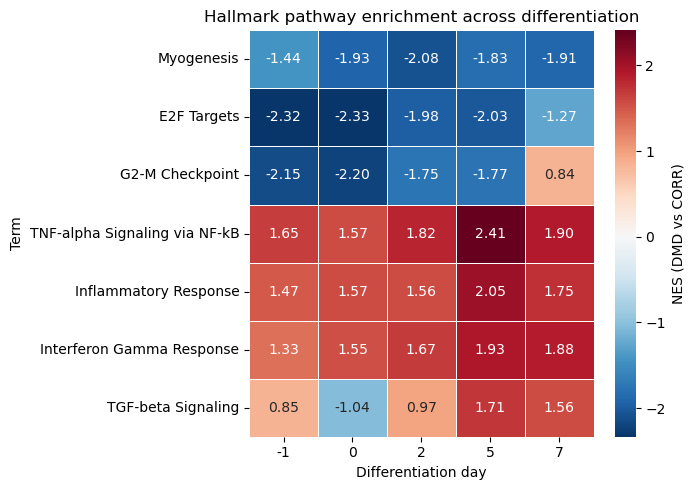

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(
    nes_matrix,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "NES (DMD vs CORR)"}
)

plt.xlabel("Differentiation day")
plt.title("Hallmark pathway enrichment across differentiation")
plt.tight_layout()
plt.savefig("../results/figures/02_1_hallmark_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

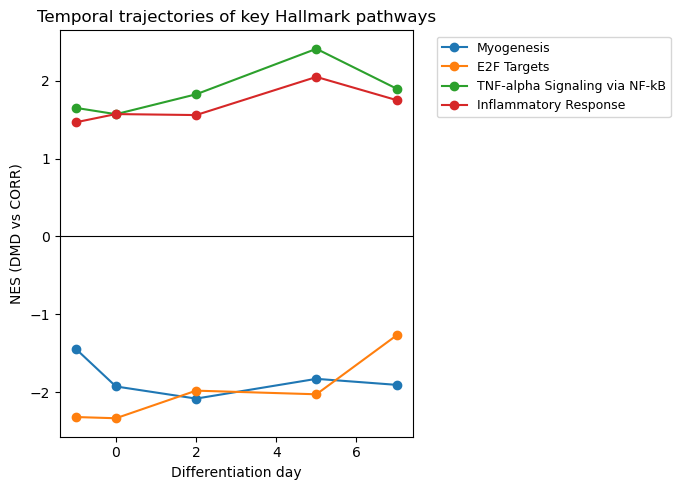

In [12]:
fig, ax = plt.subplots(figsize=(7, 5))

for pathway in ["Myogenesis", "E2F Targets", "TNF-alpha Signaling via NF-kB", "Inflammatory Response"]:
    ax.plot(days, nes_matrix.loc[pathway], marker="o", label=pathway)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Differentiation day")
ax.set_ylabel("NES (DMD vs CORR)")
ax.set_title("Temporal trajectories of key Hallmark pathways")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig("../results/figures/02_2_temporal_trajectories.png", dpi=150, bbox_inches="tight")
plt.show()